In [1]:
import yt
import numpy as np
#from yt.mods import *
from yt.frontends.boxlib.api import NyxDataset, AMReXDataset
from yt.data_objects.time_series import DatasetSeries
import matplotlib.pyplot as plt
from matplotlib import rc_context
from matplotlib.animation import FuncAnimation
from IPython import display

In [2]:
class AMReXDatasetSeries(DatasetSeries):
    _dataset_cls = AMReXDataset

In [3]:
path = "../Outputs//plt0????"
dsLoad = AMReXDatasetSeries(path)

In [4]:
ds = []
for data in dsLoad:
    ds.append(data)

yt : [INFO     ] 2026-08-17 10:27:38,210 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-08-17 10:27:38,211 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2026-08-17 10:27:38,211 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-08-17 10:27:38,212 Parameters: domain_right_edge         = [20. 20. 20.]
yt : [INFO     ] 2026-08-17 10:27:38,235 Parameters: current_time              = 10.0
yt : [INFO     ] 2026-08-17 10:27:38,236 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2026-08-17 10:27:38,236 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-08-17 10:27:38,237 Parameters: domain_right_edge         = [20. 20. 20.]
yt : [INFO     ] 2026-08-17 10:27:38,262 Parameters: current_time              = 20.0000000000001
yt : [INFO     ] 2026-08-17 10:27:38,263 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2026-08-17 10:27:38,263 Parameters: domain_left_edge   

In [7]:
def _relE (field, dat):
    av = dat.ds.all_data().quantities.weighted_average_quantity("Edens", weight = ("index", "ones"))
    return dat["Edens"]/av
for data in ds:
    data.add_field(("boxlib","EdensRel"), function=_relE, sampling_type="local", units="dimensionless",force_override=True)

TypeError: Received field function <function _relE at 0x7187945e4f70> with invalid signature. Expected exactly 2 positional parameters ('field', 'data'), got ('field', 'dat')

In [5]:
ds_test = ds[0]
ds_test.field_list

[('boxlib', 'Edens'),
 ('boxlib', 'KGf'),
 ('boxlib', 'KGfVpr'),
 ('boxlib', 'KGfdens'),
 ('boxlib', 'KGfpr'),
 ('boxlib', 'KGfv')]

yt : [INFO     ] 2026-08-17 10:27:49,695 xlim = 0.000000 20.000000
yt : [INFO     ] 2026-08-17 10:27:49,696 ylim = 0.000000 20.000000
yt : [INFO     ] 2026-08-17 10:27:49,698 xlim = 0.000000 20.000000
yt : [INFO     ] 2026-08-17 10:27:49,698 ylim = 0.000000 20.000000
yt : [INFO     ] 2026-08-17 10:27:49,701 Making a fixed resolution buffer of (('boxlib', 'Edens')) 800 by 800
/home/lsou343/.local/lib/python3.10/site-packages/unyt/array.py:1949: RuntimeWarning: invalid value encountered in divide
  out_arr = func(
/home/lsou343/.local/lib/python3.10/site-packages/yt/visualization/image_writer.py:269: RuntimeWarning: invalid value encountered in cast
  mapped = np.dstack([(np.interp(buff, x, v) * 255).astype("uint8") for v in lut])



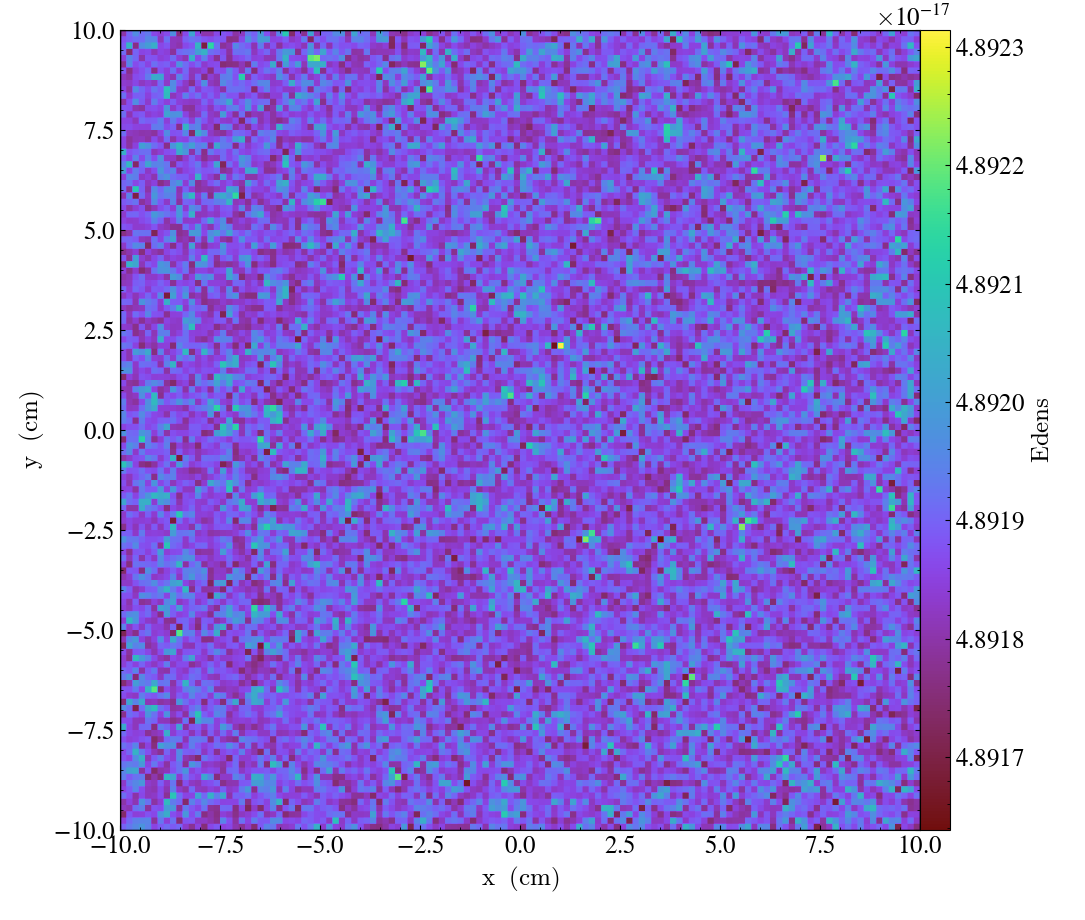

In [6]:
field = "Edens"
plot = yt.SlicePlot(ds[0], "z", field)#, center = [0,0,0])
#plot.set_zlim(("boxlib", "KGfdens"), 1e-13, 2e1)
plot.set_log(field, False)
#plot.show()
plot.annotate_grids()

In [7]:
fig = plot.plots[("boxlib", field)].figure

In [8]:
def animate(i):
    ts = ds[i]
    plot._switch_ds(ts)

In [9]:
animation = FuncAnimation(fig, animate, frames=len(ds))

In [10]:
# Override matplotlib's defaults to get a nicer looking font
with rc_context({"mathtext.fontset": "stix"}):
    #animation.save("animation.mp4")
    video = animation.to_html5_video()
    html = display.HTML(video)
    display.display(html)

/home/lsou343/.local/lib/python3.10/site-packages/unyt/array.py:1949: RuntimeWarning: invalid value encountered in divide
  out_arr = func(
/home/lsou343/.local/lib/python3.10/site-packages/yt/visualization/image_writer.py:269: RuntimeWarning: invalid value encountered in cast
  mapped = np.dstack([(np.interp(buff, x, v) * 255).astype("uint8") for v in lut])


In [31]:
animation.save(f'animation {field}.mp4',fps=4)

/home/lsou343/.local/lib/python3.10/site-packages/unyt/array.py:1949: RuntimeWarning: invalid value encountered in divide
  out_arr = func(
/home/lsou343/.local/lib/python3.10/site-packages/yt/visualization/image_writer.py:269: RuntimeWarning: invalid value encountered in cast
  mapped = np.dstack([(np.interp(buff, x, v) * 255).astype("uint8") for v in lut])


In [11]:
from matplotlib.animation import PillowWriter
writer = PillowWriter(fps=10,
                                 metadata=dict(artist='Me'),
                                 bitrate=1800)
animation.save(f'animation {field}.gif', writer=writer)


/home/lsou343/.local/lib/python3.10/site-packages/unyt/array.py:1949: RuntimeWarning: invalid value encountered in divide
  out_arr = func(
/home/lsou343/.local/lib/python3.10/site-packages/yt/visualization/image_writer.py:269: RuntimeWarning: invalid value encountered in cast
  mapped = np.dstack([(np.interp(buff, x, v) * 255).astype("uint8") for v in lut])


yt : [INFO     ] 2026-08-10 11:16:19,706 xlim = 0.000000 20.000000
yt : [INFO     ] 2026-08-10 11:16:19,706 ylim = 0.000000 20.000000
yt : [INFO     ] 2026-08-10 11:16:19,709 xlim = 0.000000 20.000000
yt : [INFO     ] 2026-08-10 11:16:19,710 ylim = 0.000000 20.000000
yt : [INFO     ] 2026-08-10 11:16:19,711 Making a fixed resolution buffer of (('boxlib', 'PhiGrav_pr')) 800 by 800
/home/lsou343/.local/lib/python3.10/site-packages/unyt/array.py:1949: RuntimeWarning: invalid value encountered in divide
  out_arr = func(
/home/lsou343/.local/lib/python3.10/site-packages/yt/visualization/image_writer.py:269: RuntimeWarning: invalid value encountered in cast
  mapped = np.dstack([(np.interp(buff, x, v) * 255).astype("uint8") for v in lut])



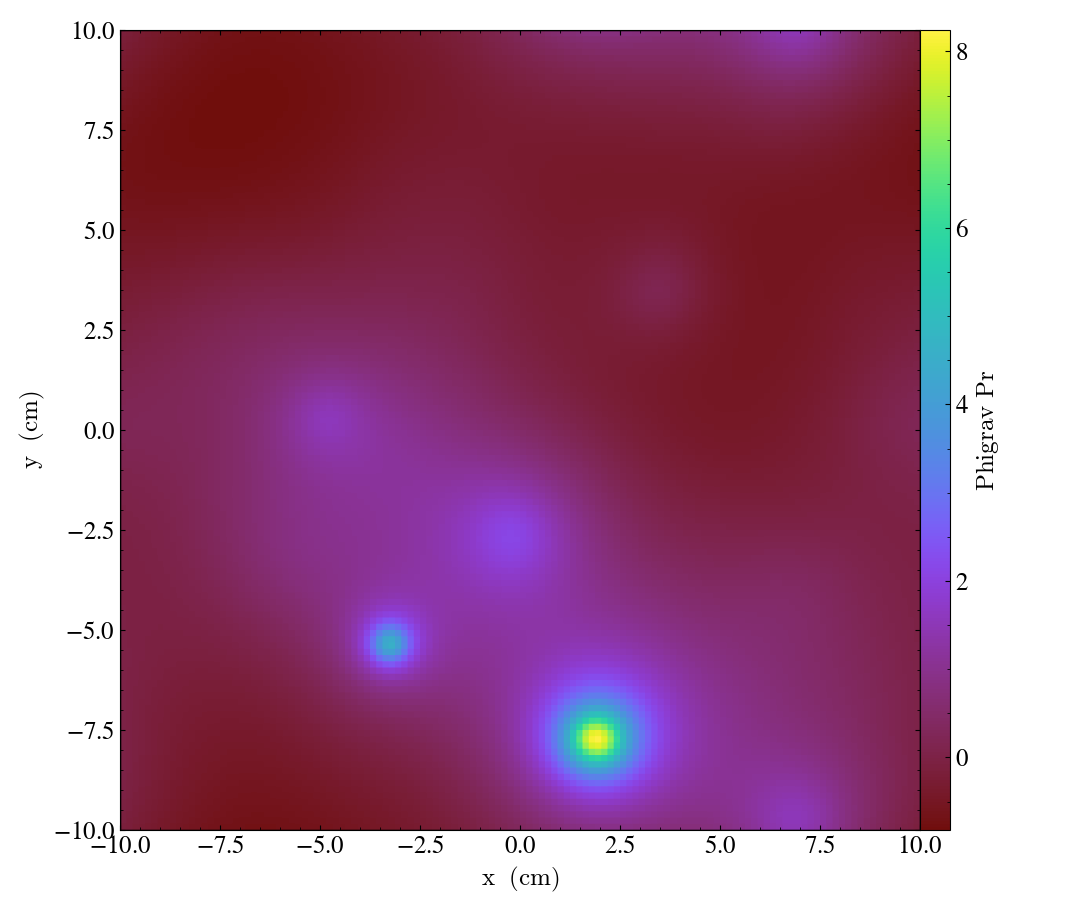

In [31]:
ds_check = ds[-1]

plot = yt.SlicePlot(ds_check, "z", field)#, center = [0,0,0])
#plot.set_zlim(("boxlib", "KGfdens"), 1e-13, 2e1)
plot.set_log(field, False)
#plot.show()
sl = plot.annotate_grids()
sl

In [32]:
sl.save()

yt : [INFO     ] 2026-08-10 11:16:23,526 Saving plot plt09800_Slice_z_PhiGrav_pr.png


['plt09800_Slice_z_PhiGrav_pr.png']

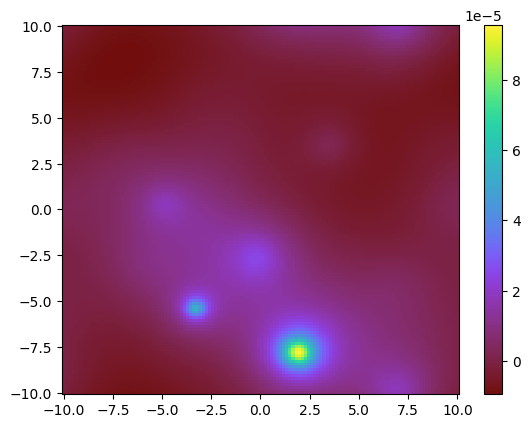

In [38]:
data = ds_check.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])["boxlib", "PhiGrav_pr"]
data = np.array(data)
coef = (6.82239161348826 * 4.300630e+01) ** 2
data /= coef
xs = np.linspace(-10,10,128)
x,y = np.meshgrid(xs,xs,indexing='ij')
plt.pcolormesh(x,y,data[:,:,64], cmap="arbre")
plt.colorbar()
plt.savefig("plt09800_Slice_z_PhiGrav.png",dpi=300)